# Test Text Line Detection

Notebook test module `src/ocr/text_detection.py` tren cac crop address/origin.

**Muc dich:**
- Kiem tra PaddleOCR det co tach duoc cac dong text trong crop dia chi/que quan
- Visualize bbox tung dong tren anh goc
- So sanh ket qua VietOCR khi doc tung dong vs doc ca crop
- Kiem tra fallback (projection, whole crop)

In [1]:
import sys
import os
from pathlib import Path

# Them project root vao sys.path
PROJECT_ROOT = Path(os.getcwd()).parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: d:\TaiLieuHocTap\Vietnamese-CCCD-Information-Extraction-System


In [2]:
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

## 1. Load sample crops

Address crops: 10
Origin crops:  10

Sample shape: (72, 484, 3)


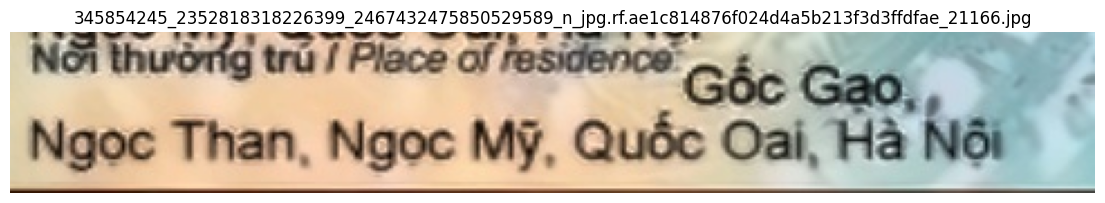

In [3]:
CROP_DIR = PROJECT_ROOT / "data" / "processed" / "ocr" / "field_crops"

address_crops = sorted(CROP_DIR.glob("address/*.jpg"))[:10]
origin_crops = sorted(CROP_DIR.glob("origin/*.jpg"))[:10]

print(f"Address crops: {len(address_crops)}")
print(f"Origin crops:  {len(origin_crops)}")

# Xem thu 1 anh
if address_crops:
    sample = cv2.imread(str(address_crops[0]))
    print(f"\nSample shape: {sample.shape}")
    plt.imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB))
    plt.title(address_crops[0].name)
    plt.axis('off')
    plt.show()

## 2. Test detect_text_lines()

In [4]:
from src.ocr.text_detection import (
    detect_text_lines,
    is_multi_line_field,
    PaddleTextDetector,
    TextLineDetectionResult,
)

# Kiem tra field nao la multi-line
for name in ["id", "name", "birth", "origin", "address",
             "id_number", "full_name", "date_of_birth",
             "place_of_origin", "place_of_residence"]:
    print(f"  {name:25s} -> multi_line = {is_multi_line_field(name)}")

  id                        -> multi_line = False
  name                      -> multi_line = False
  birth                     -> multi_line = False
  origin                    -> multi_line = True
  address                   -> multi_line = True
  id_number                 -> multi_line = False
  full_name                 -> multi_line = False
  date_of_birth             -> multi_line = False
  place_of_origin           -> multi_line = True
  place_of_residence        -> multi_line = True


In [5]:
# Khoi tao detector (chi load 1 lan)
detector = PaddleTextDetector()
print("PaddleTextDetector initialized (model loads on first detect call)")

PaddleTextDetector initialized (model loads on first detect call)


In [6]:
def visualize_detection(image_path, field_name, detector=None):
    """Chay detect_text_lines va visualize ket qua."""
    image = cv2.imread(str(image_path))
    if image is None:
        print(f"ERROR: Cannot read {image_path}")
        return None

    result = detect_text_lines(image, field_name, detector=detector)

    # --- Plot ---
    n_lines = len(result.lines)
    fig, axes = plt.subplots(1, n_lines + 1, figsize=(4 * (n_lines + 1), 4))
    if n_lines + 1 == 1:
        axes = [axes]

    # Anh goc voi bbox
    ax = axes[0]
    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    colors = ['#FF0000', '#00FF00', '#0000FF', '#FF00FF', '#FFFF00']
    for i, line in enumerate(result.lines):
        x1, y1, x2, y2 = line.bbox_xyxy
        color = colors[i % len(colors)]
        rect = Rectangle((x1, y1), x2 - x1, y2 - y1,
                          linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1 - 3, f"L{i}", color=color, fontsize=10, fontweight='bold')
    ax.set_title(f"Detected lines: {n_lines}\nMethod: {result.method}", fontsize=9)
    ax.axis('off')

    # Tung dong crop
    for i, line in enumerate(result.lines):
        ax = axes[i + 1]
        crop_rgb = cv2.cvtColor(line.crop, cv2.COLOR_BGR2RGB) if line.crop.ndim == 3 else line.crop
        ax.imshow(crop_rgb)
        det_text = line.det_text or ""
        ax.set_title(
            f"Line {i} | conf={line.detection_confidence:.2f}\n"
            f"det_text: {det_text[:40]}",
            fontsize=8,
        )
        ax.axis('off')

    fig.suptitle(Path(image_path).name, fontsize=10, y=1.02)
    plt.tight_layout()
    plt.show()

    # Print info
    print(f"  Method: {result.method}")
    print(f"  Raw lines: {result.num_lines_raw} -> Filtered: {result.num_lines_filtered}")
    if result.warnings:
        for w in result.warnings:
            print(f"  WARNING: {w}")
    for line in result.lines:
        h, w = line.crop.shape[:2]
        print(f"  Line {line.line_index}: {w}x{h}px, conf={line.detection_confidence:.3f}, "
              f"method={line.method}, det_text='{line.det_text or ''}'")
    print()
    return result

### 2a. Test tren Address crops

PaddleOCR det failed, trying projection: PaddleOCR is required for text line detection. Install with: pip install paddleocr paddlepaddle


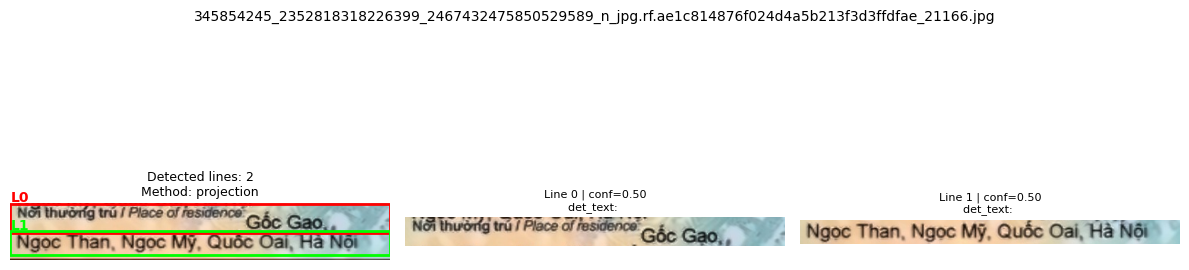

PaddleOCR det failed, trying projection: PaddleOCR is required for text line detection. Install with: pip install paddleocr paddlepaddle


  Method: projection
  Raw lines: 2 -> Filtered: 2
  Line 0: 484x37px, conf=0.500, method=projection, det_text=''
  Line 1: 484x30px, conf=0.500, method=projection, det_text=''



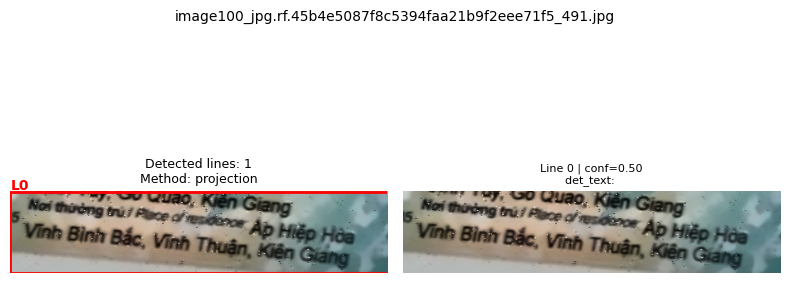

PaddleOCR det failed, trying projection: PaddleOCR is required for text line detection. Install with: pip install paddleocr paddlepaddle


  Method: projection
  Raw lines: 1 -> Filtered: 1
  Line 0: 477x103px, conf=0.500, method=projection, det_text=''



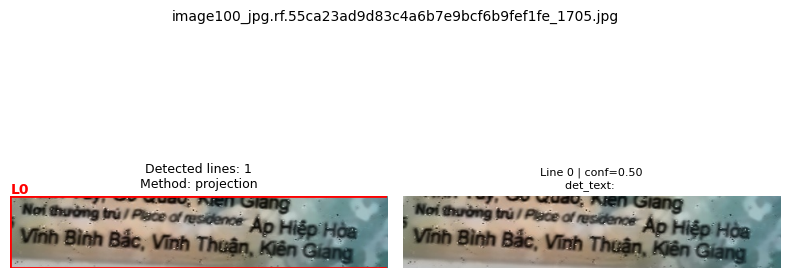

PaddleOCR det failed, trying projection: PaddleOCR is required for text line detection. Install with: pip install paddleocr paddlepaddle


  Method: projection
  Raw lines: 1 -> Filtered: 1
  Line 0: 474x91px, conf=0.500, method=projection, det_text=''



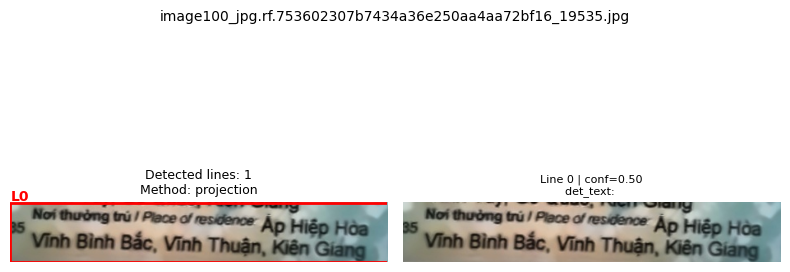

PaddleOCR det failed, trying projection: PaddleOCR is required for text line detection. Install with: pip install paddleocr paddlepaddle


  Method: projection
  Raw lines: 1 -> Filtered: 1
  Line 0: 460x73px, conf=0.500, method=projection, det_text=''



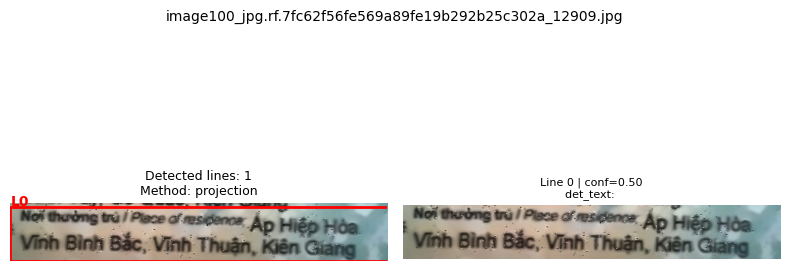

  Method: projection
  Raw lines: 1 -> Filtered: 1
  Line 0: 496x71px, conf=0.500, method=projection, det_text=''



In [7]:
address_results = []
for crop_path in address_crops[:5]:
    r = visualize_detection(crop_path, "address", detector=detector)
    if r:
        address_results.append((crop_path, r))

### 2b. Test tren Origin crops

PaddleOCR det failed, trying projection: PaddleOCR is required for text line detection. Install with: pip install paddleocr paddlepaddle


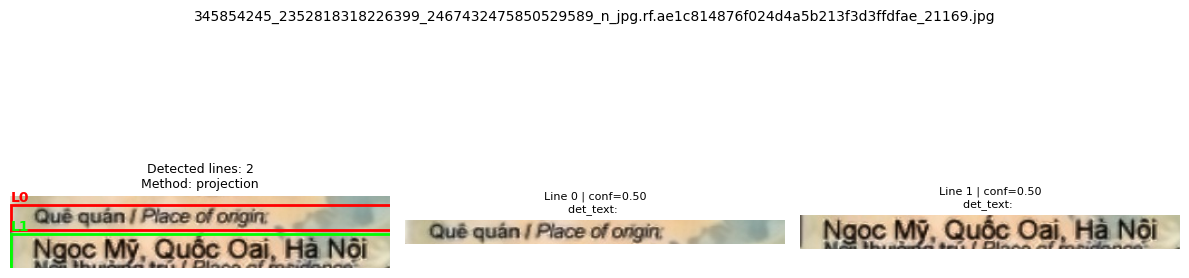

PaddleOCR det failed, trying projection: PaddleOCR is required for text line detection. Install with: pip install paddleocr paddlepaddle


  Method: projection
  Raw lines: 2 -> Filtered: 2
  Line 0: 341x22px, conf=0.500, method=projection, det_text=''
  Line 1: 341x31px, conf=0.500, method=projection, det_text=''



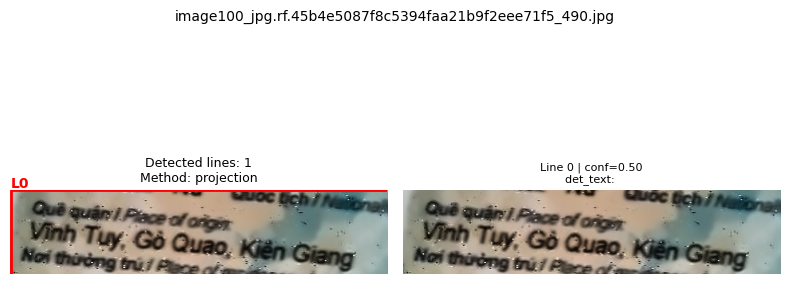

PaddleOCR det failed, trying projection: PaddleOCR is required for text line detection. Install with: pip install paddleocr paddlepaddle


  Method: projection
  Raw lines: 1 -> Filtered: 1
  Line 0: 377x84px, conf=0.500, method=projection, det_text=''



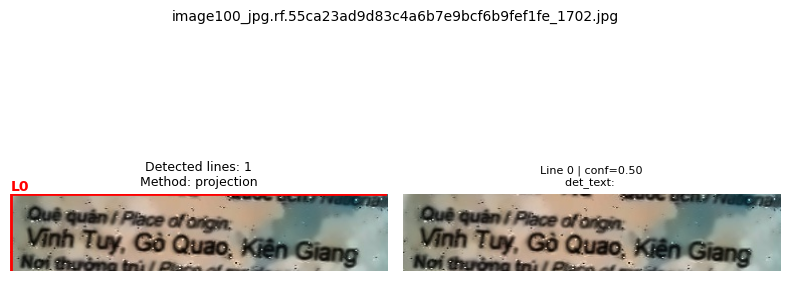

PaddleOCR det failed, trying projection: PaddleOCR is required for text line detection. Install with: pip install paddleocr paddlepaddle


  Method: projection
  Raw lines: 1 -> Filtered: 1
  Line 0: 376x77px, conf=0.500, method=projection, det_text=''



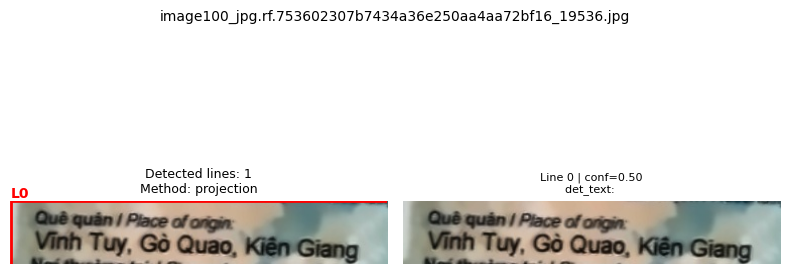

PaddleOCR det failed, trying projection: PaddleOCR is required for text line detection. Install with: pip install paddleocr paddlepaddle


  Method: projection
  Raw lines: 1 -> Filtered: 1
  Line 0: 375x63px, conf=0.500, method=projection, det_text=''



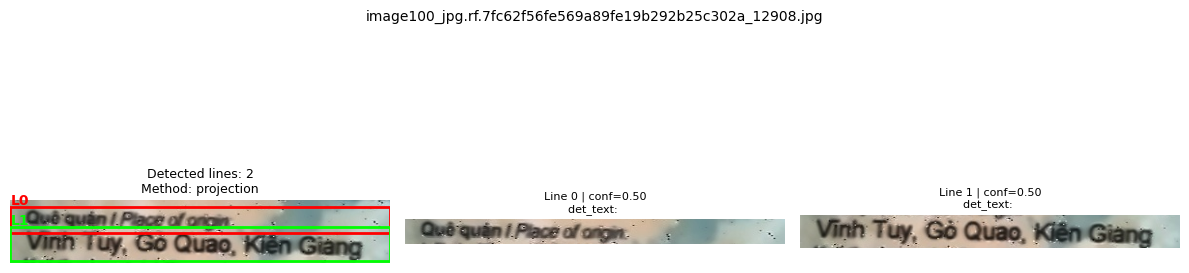

  Method: projection
  Raw lines: 2 -> Filtered: 2
  Line 0: 393x26px, conf=0.500, method=projection, det_text=''
  Line 1: 393x35px, conf=0.500, method=projection, det_text=''



In [8]:
origin_results = []
for crop_path in origin_crops[:5]:
    r = visualize_detection(crop_path, "origin", detector=detector)
    if r:
        origin_results.append((crop_path, r))

## 3. So sanh VietOCR: whole crop vs per-line

Day la test quan trong nhat: so sanh output khi:
- **A**: Feed ca crop vao VietOCR (cach cu - hay bi hallucinate)
- **B**: Tach dong bang text detection, feed tung dong vao VietOCR roi noi lai

In [ ]:
from src.ocr.vietocr_adapter import VietOCRRecognizer

vietocr = VietOCRRecognizer()
print("VietOCR initialized (model loads on first recognize call)")

In [ ]:
def compare_ocr(image_path, field_name, detector, vietocr):
    """So sanh OCR whole crop vs per-line."""
    image = cv2.imread(str(image_path))
    if image is None:
        return

    # --- A: Whole crop (cach cu) ---
    whole_result = vietocr.recognize(image, field_name=field_name)

    # --- B: Per-line (cach moi) ---
    det_result = detect_text_lines(image, field_name, detector=detector)
    line_texts = []
    line_scores = []
    for line in det_result.lines:
        ocr = vietocr.recognize(line.crop, field_name=field_name)
        line_texts.append(ocr.text)
        line_scores.append(ocr.score)

    joined_text = ", ".join(t for t in line_texts if t.strip())
    avg_score = np.mean(line_scores) if line_scores else 0.0

    # --- Display ---
    fig, axes = plt.subplots(1, len(det_result.lines) + 1,
                             figsize=(4 * (len(det_result.lines) + 1), 3))
    if len(det_result.lines) + 1 == 1:
        axes = [axes]

    axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Whole crop\n\"{whole_result.text}\"\nscore={whole_result.score:.3f}", fontsize=8)
    axes[0].axis('off')

    for i, line in enumerate(det_result.lines):
        crop_rgb = cv2.cvtColor(line.crop, cv2.COLOR_BGR2RGB) if line.crop.ndim == 3 else line.crop
        axes[i + 1].imshow(crop_rgb)
        axes[i + 1].set_title(
            f"Line {i}\n\"{line_texts[i]}\"\nscore={line_scores[i]:.3f}",
            fontsize=8,
        )
        axes[i + 1].axis('off')

    fig.suptitle(Path(image_path).name, fontsize=9, y=1.05)
    plt.tight_layout()
    plt.show()

    print(f"  [A] Whole crop : \"{whole_result.text}\" (score={whole_result.score:.3f})")
    print(f"  [B] Per-line   : \"{joined_text}\" (avg_score={avg_score:.3f})")
    print(f"  Detection method: {det_result.method}, lines: {len(det_result.lines)}")
    print()

    return {
        "file": Path(image_path).name,
        "whole_text": whole_result.text,
        "whole_score": whole_result.score,
        "per_line_text": joined_text,
        "per_line_score": avg_score,
        "method": det_result.method,
        "num_lines": len(det_result.lines),
    }

### 3a. So sanh tren Address

In [ ]:
address_comparisons = []
for crop_path in address_crops[:5]:
    r = compare_ocr(crop_path, "address", detector, vietocr)
    if r:
        address_comparisons.append(r)

### 3b. So sanh tren Origin

In [ ]:
origin_comparisons = []
for crop_path in origin_crops[:5]:
    r = compare_ocr(crop_path, "origin", detector, vietocr)
    if r:
        origin_comparisons.append(r)

## 4. Tong hop ket qua

In [ ]:
all_comparisons = address_comparisons + origin_comparisons

if all_comparisons:
    print(f"{'File':<60} {'Method':<15} {'Lines':>5}  {'Whole score':>11}  {'PerLine score':>13}")
    print("-" * 110)
    for c in all_comparisons:
        print(f"{c['file']:<60} {c['method']:<15} {c['num_lines']:>5}  "
              f"{c['whole_score']:>11.3f}  {c['per_line_score']:>13.3f}")

    whole_scores = [c['whole_score'] for c in all_comparisons]
    perline_scores = [c['per_line_score'] for c in all_comparisons]
    print(f"\nAvg whole crop score:  {np.mean(whole_scores):.3f}")
    print(f"Avg per-line score:    {np.mean(perline_scores):.3f}")
else:
    print("No comparisons to show.")

## 5. Test fallback: projection profile

Test rieng ham `_detect_lines_by_projection` (ko can PaddleOCR)

In [ ]:
from src.ocr.text_detection import _detect_lines_by_projection

if address_crops:
    sample = cv2.imread(str(address_crops[0]))
    boxes = _detect_lines_by_projection(sample)

    fig, axes = plt.subplots(1, len(boxes) + 1, figsize=(4 * (len(boxes) + 1), 3))
    if len(boxes) + 1 == 1:
        axes = [axes]

    img_rgb = cv2.cvtColor(sample, cv2.COLOR_BGR2RGB)
    axes[0].imshow(img_rgb)
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box
        rect = Rectangle((x1, y1), x2 - x1, y2 - y1,
                          linewidth=2, edgecolor='red', facecolor='none')
        axes[0].add_patch(rect)
    axes[0].set_title(f"Projection: {len(boxes)} lines", fontsize=9)
    axes[0].axis('off')

    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box.astype(int)
        crop = sample[y1:y2, x1:x2]
        axes[i + 1].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        axes[i + 1].set_title(f"Line {i}: {x2-x1}x{y2-y1}px", fontsize=8)
        axes[i + 1].axis('off')

    plt.suptitle(f"Projection fallback - {address_crops[0].name}", fontsize=9)
    plt.tight_layout()
    plt.show()
    print(f"Projection found {len(boxes)} lines")

## 6. Batch test nhieu anh hon (optional)

Chay tren nhieu anh de xem thong ke tong quan.

In [ ]:
N = 20  # So luong anh test (tang len neu muon)

batch_results = {"address": [], "origin": []}

for field_name, crops in [("address", address_crops[:N]), ("origin", origin_crops[:N])]:
    for crop_path in crops:
        image = cv2.imread(str(crop_path))
        if image is None:
            continue
        result = detect_text_lines(image, field_name, detector=detector)
        batch_results[field_name].append({
            "file": crop_path.name,
            "method": result.method,
            "num_lines": len(result.lines),
            "raw": result.num_lines_raw,
            "filtered": result.num_lines_filtered,
            "warnings": result.warnings,
        })

for field_name, results in batch_results.items():
    if not results:
        continue
    methods = [r['method'] for r in results]
    n_lines = [r['num_lines'] for r in results]
    print(f"\n=== {field_name.upper()} ({len(results)} samples) ===")
    print(f"  Methods: {dict((m, methods.count(m)) for m in set(methods))}")
    print(f"  Avg lines: {np.mean(n_lines):.1f}")
    print(f"  Lines distribution: {dict((n, n_lines.count(n)) for n in sorted(set(n_lines)))}")
    n_warnings = sum(1 for r in results if r['warnings'])
    print(f"  Samples with warnings: {n_warnings}/{len(results)}")
    if n_warnings:
        for r in results:
            if r['warnings']:
                print(f"    {r['file']}: {r['warnings']}")

## 7. Test voi anh cu the (tuy chon)

Doi duong dan thanh anh ban muon test.

In [ ]:
# Doi duong dan anh o day
# custom_image_path = PROJECT_ROOT / "data" / "processed" / "ocr" / "field_crops" / "address" / "ten_file.jpg"
# visualize_detection(custom_image_path, "address", detector=detector)
# compare_ocr(custom_image_path, "address", detector, vietocr)

## 8. Test recognize_multiline_field() (full pipeline)

Test ham orchestrator hoan chinh: detect line → strip label → VietOCR per line → join → fallback.

Day la ham se duoc goi trong pipeline thuc te.

In [ ]:
from src.ocr.multiline_ocr import recognize_multiline_field

print("recognize_multiline_field loaded OK")

In [ ]:
def test_multiline(image_path, field_name, detector, vietocr):
    """So sanh: VietOCR thang (cu) vs recognize_multiline_field (moi)."""
    image = cv2.imread(str(image_path))
    if image is None:
        print(f"ERROR: Cannot read {image_path}")
        return None

    # Cach cu: VietOCR doc ca crop
    old_result = vietocr.recognize(image, field_name=field_name)

    # Cach moi: multiline pipeline
    new_result = recognize_multiline_field(image, field_name, vietocr, detector=detector)

    # Lay metadata
    raw = new_result.raw or {}
    method = raw.get("method", "?")
    num_lines = raw.get("num_lines", 0)
    per_line_texts = raw.get("per_line_texts", [])

    # Display
    print(f"--- {Path(image_path).name} ---")
    print(f"  [OLD] VietOCR whole:  \"{old_result.text}\"  (score={old_result.score:.3f})")
    print(f"  [NEW] Multiline:      \"{new_result.text}\"  (score={new_result.score:.3f})")
    print(f"        Method: {method} | Lines: {num_lines}")
    if per_line_texts:
        for i, t in enumerate(per_line_texts):
            print(f"        Line {i}: \"{t}\"")
    if raw.get("warnings"):
        print(f"        Warnings: {raw['warnings']}")
    print()

    return {
        "file": Path(image_path).name,
        "old_text": old_result.text,
        "old_score": old_result.score,
        "new_text": new_result.text,
        "new_score": new_result.score,
        "method": method,
        "num_lines": num_lines,
    }

### 8a. Address

In [ ]:
multiline_address = []
for crop_path in address_crops[:5]:
    r = test_multiline(crop_path, "address", detector, vietocr)
    if r:
        multiline_address.append(r)

### 8b. Origin

In [ ]:
multiline_origin = []
for crop_path in origin_crops[:5]:
    r = test_multiline(crop_path, "origin", detector, vietocr)
    if r:
        multiline_origin.append(r)

### 8c. Tong hop OLD vs NEW

In [ ]:
all_multiline = multiline_address + multiline_origin

if all_multiline:
    print(f"{'File':<55} {'OLD score':>9} {'NEW score':>9} {'Lines':>5}  Method")
    print("-" * 100)
    for r in all_multiline:
        marker = ""
        if r["new_score"] > r["old_score"] + 0.05:
            marker = " ✓ better"
        elif r["old_score"] > r["new_score"] + 0.05:
            marker = " ✗ worse"
        print(f"{r['file']:<55} {r['old_score']:>9.3f} {r['new_score']:>9.3f} {r['num_lines']:>5}  {r['method']}{marker}")

    old_avg = np.mean([r["old_score"] for r in all_multiline])
    new_avg = np.mean([r["new_score"] for r in all_multiline])
    print(f"\nAvg OLD score: {old_avg:.3f}")
    print(f"Avg NEW score: {new_avg:.3f}")
    print(f"Improvement:   {new_avg - old_avg:+.3f}")
else:
    print("No results.")